## Import Libraries

In [1]:
!pip install imbalanced-learn --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import warnings
import os
warnings.filterwarnings("ignore")

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE

print("All imports successful")

All imports successful


### GPU Setup

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU found. Go to Runtime > Change Runtime Type > GPU")

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


### Config

In [ ]:
RANDOM_STATE        = 42
BATCH_SIZE          = 128
EPOCHS              = 150
LR                  = 1e-3
DROPOUT             = 0.3
EARLY_STOP_PATIENCE = 20
NUM_CLASSES         = 4
LABEL_NAMES         = ["Normal (N)", "AF (A)", "Other (O)", "Noisy (~)"]

CSV_PATH      = "/content/ecg_features.csv"

CHECKPOINT_BEST   = "/content/best_mlp_model.pt"
CHECKPOINT_LATEST = "/content/latest_mlp_model.pt"
HISTORY_PATH      = "/content/mlp_history.npy"

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Config loaded")
print(f"CSV path: {CSV_PATH}")
print(f"File exists: {os.path.exists(CSV_PATH)}")

Config loaded
CSV path: /content/ecg_features.csv
File exists: True


### Load and Prepare Data

In [5]:
features_df = pd.read_csv(CSV_PATH)
print(f"Raw shape: {features_df.shape}")

missing = features_df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(f"Missing values found:\n{missing}")
else:
    print("No missing values")

features_df = features_df.dropna()
print(f"Shape after dropna: {features_df.shape}")

label_encoding = {"N": 0, "A": 1, "O": 2, "~": 3}

X = features_df.drop(columns=["record_id", "label"]).values.astype(np.float32)
y = features_df["label"].map(label_encoding).values.astype(np.int64)

INPUT_DIM = X.shape[1]
print(f"\nInput features: {INPUT_DIM}")
print(f"Total samples:  {len(X)}")

print(f"\nClass distribution:")
for label, idx in label_encoding.items():
    print(f"  {label}: {np.sum(y == idx)}")

Raw shape: (8519, 41)
Missing values found:
rr_kurtosis    2
dtype: int64
Shape after dropna: (8517, 41)

Input features: 39
Total samples:  8517

Class distribution:
  N: 5050
  A: 738
  O: 2446
  ~: 283


### Train Test Split, SMOTE, Scaling

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    stratify     = y,
    random_state = RANDOM_STATE
)

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
for label, idx in label_encoding.items():
    print(f"  {label}: {np.sum(y_train_bal == idx)}")

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)

print(f"\nScaling done")
print(f"X_train_sc: {X_train_sc.shape}")
print(f"X_test_sc:  {X_test_sc.shape}")

Train: 6813  |  Test: 1704

After SMOTE:
  N: 4040
  A: 4040
  O: 4040
  ~: 4040

Scaling done
X_train_sc: (16160, 39)
X_test_sc:  (1704, 39)


### DataLoaders

In [ ]:
train_dataset = TensorDataset(
    torch.tensor(X_train_sc),
    torch.tensor(y_train_bal)
)
test_dataset = TensorDataset(
    torch.tensor(X_test_sc),
    torch.tensor(y_test)
)

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 2,
    pin_memory  = True
)
test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 127
Test batches:  14


### Model Architecture

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim, out_dim),
            nn.BatchNorm1d(out_dim),
        )
        self.projection = (
            nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.block(x) + self.projection(x))


class ResidualMLP(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=DROPOUT):
        super().__init__()

        self.embedding = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.res1 = ResidualBlock(256, 256, dropout)
        self.res2 = ResidualBlock(256, 128, dropout)
        self.res3 = ResidualBlock(128, 64,  dropout)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.embedding(x)
        x = self.res1(x)
        x = self.res2(x)
        x = self.res3(x)
        return self.classifier(x)


model = ResidualMLP(INPUT_DIM, NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: ResidualMLP")
print(f"Trainable parameters: {total_params:,}")
print(f"Device: {next(model.parameters()).device}")

Model: ResidualMLP
Trainable parameters: 247,364
Device: cuda:0


### Loss, Optimizer, Scheduler

In [ ]:
class_weights = np.array([1.0, 3.0, 2.5, 2.0])  # N, A, O, ~
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:")
for label, idx in label_encoding.items():
    print(f"  {label}: {class_weights_tensor[idx].item():.4f}")

criterion = nn.CrossEntropyLoss(
    weight          = class_weights_tensor,
    label_smoothing = 0.1
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = LR,
    weight_decay = 1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = "min",
    factor   = 0.5,
    patience = 10,
    min_lr   = 1e-6
)

print(f"\nPyTorch version: {torch.__version__}")
print("Criterion, optimizer, scheduler ready")

Class weights:
  N: 1.0000
  A: 3.0000
  O: 2.5000
  ~: 2.0000

PyTorch version: 2.10.0+cu128
Criterion, optimizer, scheduler ready


### Training Functions

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(dim=1) == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            logits = model(X_batch)
            loss   = criterion(logits, y_batch)

            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(dim=1) == y_batch).sum().item()
            total      += len(y_batch)

            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_targets))

print("Training functions defined")

Training functions defined


### Load Checkpoint or Start Fresh

In [12]:
start_epoch   = 0
best_val_loss = float("inf")
history       = {"train_loss": [], "val_loss": [],
                 "train_acc":  [], "val_acc":  []}
patience_counter = 0

if os.path.exists(CHECKPOINT_LATEST):
    ckpt = torch.load(CHECKPOINT_LATEST, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    start_epoch      = ckpt["epoch"] + 1
    best_val_loss    = ckpt["best_val_loss"]
    patience_counter = ckpt.get("patience_counter", 0)
    print(f"Resumed from epoch {start_epoch}")
    print(f"Best val loss so far: {best_val_loss:.4f}")
else:
    print("No checkpoint found, starting fresh")

if os.path.exists(HISTORY_PATH):
    history = np.load(HISTORY_PATH, allow_pickle=True).item()
    print(f"History loaded: {len(history['train_loss'])} epochs completed")

epochs_remaining = EPOCHS - start_epoch
print(f"Epochs remaining: {epochs_remaining}")

No checkpoint found, starting fresh
Epochs remaining: 150


### Train

In [ ]:
if start_epoch >= EPOCHS:
    print("Training already complete. Run evaluation cell.")
else:
    print(f"Training from epoch {start_epoch + 1} to {EPOCHS}")
    print("=" * 70)

    for epoch in range(start_epoch, EPOCHS):

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc, _, _ = evaluate(
            model, test_loader, criterion, device
        )

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch + 1:>3}/{EPOCHS}  "
              f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

        torch.save({
            "epoch":            epoch,
            "model_state":      model.state_dict(),
            "optimizer_state":  optimizer.state_dict(),
            "best_val_loss":    best_val_loss,
            "patience_counter": patience_counter,
        }, CHECKPOINT_LATEST)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                "epoch":           epoch,
                "model_state":     model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "best_val_loss":   best_val_loss,
            }, CHECKPOINT_BEST)
            print(f"  >>> Best model saved (epoch {epoch + 1})")
        else:
            patience_counter += 1

        np.save(HISTORY_PATH, history)

        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch + 1}")
            break

    print("\nTraining complete")

Training from epoch 1 to 150
Epoch   1/150  Train Loss: 0.8473  Acc: 0.6609  Val Loss: 1.0958  Acc: 0.6080
  >>> Best model saved (epoch 1)
Epoch   2/150  Train Loss: 0.7241  Acc: 0.7507  Val Loss: 1.0553  Acc: 0.5927
  >>> Best model saved (epoch 2)
Epoch   3/150  Train Loss: 0.6903  Acc: 0.7649  Val Loss: 1.0449  Acc: 0.6097
  >>> Best model saved (epoch 3)
Epoch   4/150  Train Loss: 0.6731  Acc: 0.7779  Val Loss: 0.9988  Acc: 0.6631
  >>> Best model saved (epoch 4)
Epoch   5/150  Train Loss: 0.6583  Acc: 0.7895  Val Loss: 1.0550  Acc: 0.6115
Epoch   6/150  Train Loss: 0.6457  Acc: 0.7955  Val Loss: 1.0321  Acc: 0.6303
Epoch   7/150  Train Loss: 0.6358  Acc: 0.8019  Val Loss: 1.0081  Acc: 0.6602
Epoch   8/150  Train Loss: 0.6229  Acc: 0.8085  Val Loss: 1.0226  Acc: 0.6590
Epoch   9/150  Train Loss: 0.6208  Acc: 0.8078  Val Loss: 0.9999  Acc: 0.6714
Epoch  10/150  Train Loss: 0.6142  Acc: 0.8140  Val Loss: 0.9922  Acc: 0.6590
  >>> Best model saved (epoch 10)
Epoch  11/150  Train Loss

###  Evaluate Best Model

In [14]:
ckpt = torch.load(CHECKPOINT_BEST, map_location=device)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded best model from epoch {ckpt['epoch'] + 1}")

_, _, y_pred, y_true = evaluate(model, test_loader, criterion, device)

acc = accuracy_score(y_true, y_pred)
print(f"\nTest Accuracy: {acc:.4f}  ({acc * 100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_true, y_pred,
                             target_names=LABEL_NAMES, digits=4))

Loaded best model from epoch 20

Test Accuracy: 0.6907  (69.07%)

Classification Report:
              precision    recall  f1-score   support

  Normal (N)     0.8896    0.6861    0.7747      1010
      AF (A)     0.5914    0.7432    0.6587       148
   Other (O)     0.5329    0.6953    0.6034       489
   Noisy (~)     0.3366    0.5965    0.4304        57

    accuracy                         0.6907      1704
   macro avg     0.5876    0.6803    0.6168      1704
weighted avg     0.7428    0.6907    0.7040      1704



### Training Curves

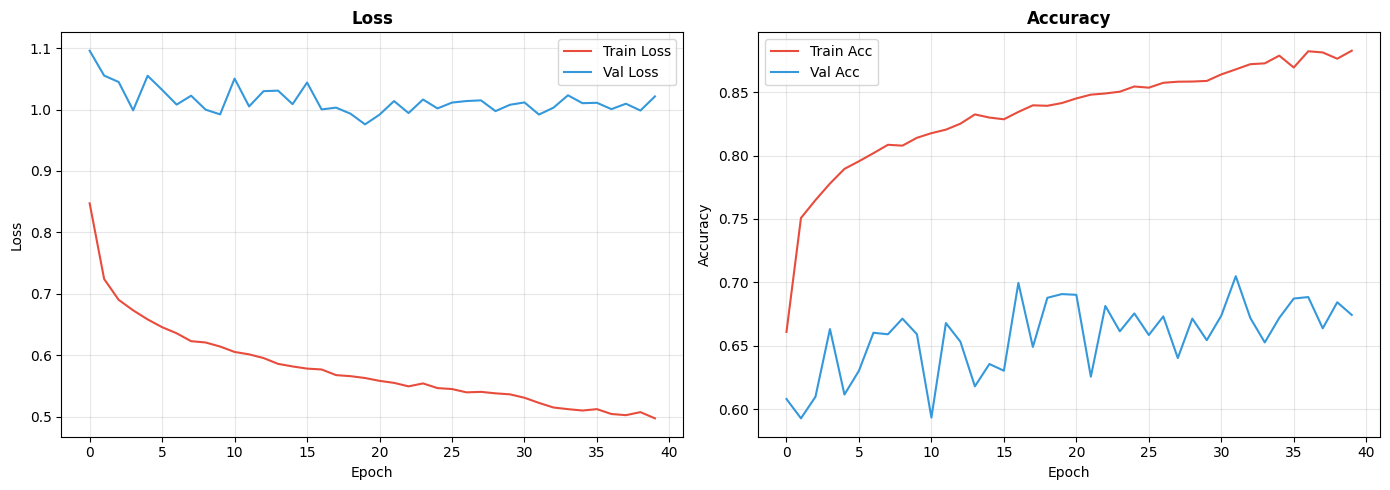

Best val accuracy: 0.7048
Best val loss:     0.9759


In [15]:
h   = np.load(HISTORY_PATH, allow_pickle=True).item()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(h["train_loss"], label="Train Loss", color="#e74c3c", linewidth=1.5)
axes[0].plot(h["val_loss"],   label="Val Loss",   color="#3498db", linewidth=1.5)
axes[0].set_title("Loss", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(h["train_acc"], label="Train Acc", color="#e74c3c", linewidth=1.5)
axes[1].plot(h["val_acc"],   label="Val Acc",   color="#3498db", linewidth=1.5)
axes[1].set_title("Accuracy", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/mlp_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best val accuracy: {max(h['val_acc']):.4f}")
print(f"Best val loss:     {min(h['val_loss']):.4f}")

### Confusion Matrix

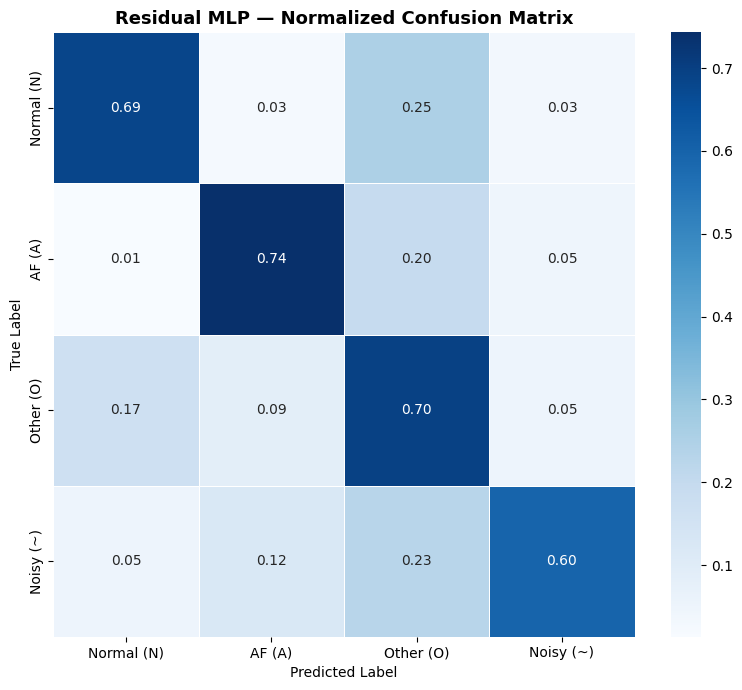

In [16]:
cm  = confusion_matrix(y_true, y_pred, normalize="true")
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.5, ax=ax)
ax.set_title("Residual MLP — Normalized Confusion Matrix",
             fontsize=13, fontweight="bold")
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("/content/mlp_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### Download Saved Files

In [17]:
from google.colab import files

files.download(CHECKPOINT_BEST)
files.download("/content/mlp_training_curves.png")
files.download("/content/mlp_confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>